In [1]:
#!/usr/bin/env julia

include(joinpath(@__DIR__, "MonteCarloMF.jl"))

using DifferentialEquations
using JLD2
using Printf
using Random
using Statistics

if !haskey(ENV, "MPLCONFIGDIR")
    mpl_config_dir = joinpath(tempdir(), "matplotlib")
    mkpath(mpl_config_dir)
    ENV["MPLCONFIGDIR"] = mpl_config_dir
end
if !haskey(ENV, "MPLBACKEND")
    ENV["MPLBACKEND"] = "Agg"
end

using PyPlot

const ROOT_DIR = normpath(joinpath(@__DIR__, ".."))

state_observable(S, M, N, Gamma, xi) = (S = S, M = M)

function dicke_Gn(S, M, n::Int)
    n >= 1 || error("correlation order n must be >= 1")

    out = 1.0
    for j in 0:(n - 1)
        out *= Float64(S + M - j) * Float64(S - M + 1 + j)
    end
    return out
end

function safe_divide(num::AbstractVector, den::AbstractVector; eps = 1e-14)
    out = Vector{Float64}(undef, length(num))
    for i in eachindex(num, den)
        out[i] = abs(den[i]) > eps ? num[i] / den[i] : NaN
    end
    return out
end

function normalize_moments(moment_matrix, orders)
    idx1 = findfirst(==(1), orders)
    idx1 === nothing && error("orders must contain n = 1")

    G1 = moment_matrix[:, idx1]
    normalized = fill(NaN, size(moment_matrix))
    for (j, n) in enumerate(orders)
        normalized[:, j] = safe_divide(moment_matrix[:, j], G1 .^ n)
    end
    return normalized
end

function simulate_full_jump_reference(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_grid,
    orders,
    n_traj::Int;
    sizehint::Int = 0,
    store_histories::Bool = true,
)
    sums = zeros(Float64, length(t_grid), length(orders))
    histories = Any[]
    store_histories && sizehint!(histories, n_traj)

    for traj in 1:n_traj
        ts, states = run_trajectory(
            N, Gamma, xi, gamma, Float64(last(t_grid)), state_observable;
            sizehint = sizehint,
        )

        if store_histories
            push!(
                histories,
                (
                    t = collect(ts),
                    S = [state.S for state in states],
                    M = [state.M for state in states],
                ),
            )
        end

        idx = 1
        for (k, t) in enumerate(t_grid)
            while idx < length(ts) && ts[idx + 1] <= t
                idx += 1
            end

            S = states[idx].S
            M = states[idx].M
            for (j, n) in enumerate(orders)
                sums[k, j] += dicke_Gn(S, M, n)
            end
        end

        if traj % max(1, n_traj ÷ 10) == 0
            @printf("  full MC: %d/%d trajectories\n", traj, n_traj)
        end
    end

    moments = sums ./ n_traj
    return (
        G = moments,
        g = normalize_moments(moments, orders),
        histories = histories,
    )
end

function run_seed_trajectory(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    c::Float64;
    M0::Int = N ÷ 2,
    S0::Int = N ÷ 2,
)
    S::Int = S0
    M::Int = M0
    t = 0.0
    threshold = c * Float64(N)
    G1 = dicke_Gn(S, M, 1)

    if G1 >= threshold
        return (reached = true, t = t, S = S, M = M, G1 = G1)
    end

    while t < t_max
        r_dec = Gamma * A_JM_minus2(S, M) + gamma * P_JM_minus_02(S, M, N)
        r_up = xi * P_JM_z_plus2(S, M, N)
        r_down = xi * P_JM_z_minus2(S, M, N)
        r_dec_down = gamma * P_JM_minus_minus2(S, M, N)
        r_dec_up = gamma * P_JM_minus_plus2(S, M, N)

        r_total = r_dec + r_up + r_down + r_dec_up + r_dec_down
        if r_total <= 1e-10
            return (reached = false, t = Inf, S = S, M = M, G1 = G1)
        end

        tau = -log(rand()) / r_total
        t_next = t + tau

        r_val = rand() * r_total
        if r_val < r_dec
            M -= 1
        elseif r_val < r_dec + r_up
            S += 1
        elseif r_val < r_dec + r_up + r_down
            S -= 1
        elseif r_val < r_dec + r_up + r_down + r_dec_up
            S += 1
            M -= 1
        else
            S -= 1
            M -= 1
        end

        t = t_next
        G1 = dicke_Gn(S, M, 1)
        if t <= t_max && G1 >= threshold
            return (reached = true, t = t, S = S, M = M, G1 = G1)
        end
    end

    return (reached = false, t = Inf, S = S, M = M, G1 = G1)
end

function simulate_seed_times(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    c::Float64,
    n_seed::Int,
)
    seeds = Vector{Any}(undef, n_seed)
    for traj in 1:n_seed
        seeds[traj] = run_seed_trajectory(N, Gamma, xi, gamma, t_max, c)
        if traj % max(1, n_seed ÷ 10) == 0
            @printf("  seed MC c = %.4g: %d/%d trajectories\n", c, traj, n_seed)
        end
    end
    return seeds
end

function solve_seed_meanfield(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    I0::Float64,
    m0::Float64;
    reltol = 1e-9,
    abstol = 1e-11,
)
    p = [Gamma, xi, N, gamma]
    prob = ODEProblem(meanfield_reduced!, [I0, m0], (0.0, t_max), p)
    return solve(
        prob,
        AutoTsit5(Rosenbrock23()),
        reltol = reltol,
        abstol = abstol,
    )
end

function reconstruct_from_seed_times(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_grid,
    seeds,
    c::Float64,
    orders;
    continuation::Symbol = :seed_state,
    reltol = 1e-9,
    abstol = 1e-11,
)
    sums = zeros(Float64, length(t_grid), length(orders))
    cache = Dict{Any, Any}()
    t_max = Float64(last(t_grid) - first(t_grid))

    for seed in seeds
        seed.reached || continue

        if continuation == :seed_state
            key = (seed.S, seed.M)
            I0 = seed.G1 / Float64(N)^2
            m0 = Float64(seed.M) / Float64(N)
        elseif continuation == :fixed
            key = :fixed
            I0 = c / Float64(N)
            m0 = 0.5
        else
            error("continuation must be :seed_state or :fixed")
        end

        sol = get!(cache, key) do
            solve_seed_meanfield(
                N, Gamma, xi, gamma, t_max, Float64(I0), Float64(m0);
                reltol = reltol,
                abstol = abstol,
            )
        end

        for (i, t) in enumerate(t_grid)
            t_rel = t - seed.t
            if t_rel < 0.0
                continue
            end

            Ifrak = max(Float64(sol(t_rel)[1]), 0.0)
            G1 = Float64(N)^2 * Ifrak
            for (j, n) in enumerate(orders)
                sums[i, j] += G1^n
            end
        end
    end

    moments = sums ./ length(seeds)
    return (
        G1_powers = moments,
        g_proxy = normalize_moments(moments, orders),
        continuation = continuation,
        n_unique_meanfield_paths = length(cache),
    )
end

function seed_time_summary(N, Gamma, seeds)
    reached = [seed.reached for seed in seeds]
    tau_reached = [N * Gamma * seed.t for seed in seeds if seed.reached]

    return (
        reached_fraction = mean(reached),
        tau0_mean = isempty(tau_reached) ? NaN : mean(tau_reached),
        tau0_std = length(tau_reached) <= 1 ? NaN : std(tau_reached),
        tau0_min = isempty(tau_reached) ? NaN : minimum(tau_reached),
        tau0_max = isempty(tau_reached) ? NaN : maximum(tau_reached),
    )
end

function comparison_summary(curve, orders; bulk_I_min = 5e-4)
    idx1 = findfirst(==(1), orders)
    full_I = curve.full_G[:, idx1] ./ curve.N^2
    seed_I = curve.seed_G1_powers[:, idx1] ./ curve.N^2
    intensity_mask = isfinite.(full_I) .& isfinite.(seed_I) .&
                     (full_I .> bulk_I_min) .& (seed_I .> bulk_I_min)

    if any(intensity_mask)
        I_diff = abs.(full_I[intensity_mask] .- seed_I[intensity_mask])
        intensity_mean_abs_error = mean(I_diff)
        intensity_max_abs_error = maximum(I_diff)
    else
        intensity_mean_abs_error = NaN
        intensity_max_abs_error = NaN
    end

    g_summaries = Any[]
    for (j, n) in enumerate(orders)
        n == 1 && continue

        g_full = curve.full_g[:, j]
        g_seed = curve.seed_g_proxy[:, j]
        mask = isfinite.(g_full) .& isfinite.(g_seed) .&
               (full_I .> bulk_I_min) .& (seed_I .> bulk_I_min)

        if any(mask)
            diff = abs.(g_full[mask] .- g_seed[mask])
            push!(
                g_summaries,
                (
                    n = n,
                    mean_abs_error = mean(diff),
                    max_abs_error = maximum(diff),
                ),
            )
        else
            push!(
                g_summaries,
                (
                    n = n,
                    mean_abs_error = NaN,
                    max_abs_error = NaN,
                ),
            )
        end
    end

    peak_full = argmax(full_I)
    peak_seed = argmax(seed_I)
    return (
        intensity_mean_abs_error = intensity_mean_abs_error,
        intensity_max_abs_error = intensity_max_abs_error,
        tau_peak_full = curve.tau[peak_full],
        tau_peak_seed = curve.tau[peak_seed],
        I_peak_full = full_I[peak_full],
        I_peak_seed = seed_I[peak_seed],
        g = g_summaries,
    )
end

function finite_mask(y)
    return isfinite.(y)
end

function plot_seed_curve(data, curve; outfile)
    mkpath(dirname(outfile))

    idx1 = findfirst(==(1), data.orders)
    full_I = curve.full_G[:, idx1] ./ data.N^2
    seed_I = curve.seed_G1_powers[:, idx1] ./ data.N^2
    tau0 = [data.N * data.Gamma * seed.t for seed in curve.seeds if seed.reached]
    orders_to_plot = [n for n in data.orders if n > 1]

    fig, axes = subplots(4, 1, figsize = (7.2, 9.0), sharex = false)
    cmap = get_cmap("viridis")
    colors = length(orders_to_plot) == 1 ?
             [cmap(0.55)] :
             [cmap(x) for x in range(0.15, 0.85, length = length(orders_to_plot))]

    bins = isempty(tau0) ? 10 : min(60, max(8, ceil(Int, sqrt(length(tau0)))))
    axes[1].hist(tau0, bins = bins, color = "0.25", alpha = 0.82)
    axes[1].set_ylabel("count")
    axes[1].set_title(@sprintf(
        "seed threshold c = %.4g, reached %.1f%%",
        curve.c,
        100 * curve.seed_summary.reached_fraction,
    ))
    axes[1].grid(true, alpha = 0.25)

    axes[2].plot(curve.tau, full_I, color = "black", lw = 1.8, label = "full MC")
    positive_seed = seed_I .> 0
    axes[2].plot(curve.tau[positive_seed], seed_I[positive_seed], color = "tab:blue", lw = 1.8, ls = "--", label = "seed + MF")
    axes[2].set_ylabel("<G1>/N^2")
    axes[2].set_yscale("log")
    axes[2].legend(frameon = false)
    axes[2].grid(true, alpha = 0.25)

    for (color, n) in zip(colors, orders_to_plot)
        j = findfirst(==(n), data.orders)
        full_mask = finite_mask(curve.full_g[:, j]) .& (full_I .> data.plot_I_min)
        seed_mask = finite_mask(curve.seed_g_proxy[:, j]) .& (seed_I .> data.plot_I_min)
        axes[3].plot(
            curve.tau[full_mask],
            curve.full_g[full_mask, j],
            color = color,
            lw = 1.7,
            label = @sprintf("full n=%d", n),
        )
        axes[3].plot(
            curve.tau[seed_mask],
            curve.seed_g_proxy[seed_mask, j],
            color = color,
            lw = 1.7,
            ls = "--",
            label = @sprintf("seed n=%d", n),
        )

        diff_mask = full_mask .& seed_mask
        axes[4].plot(
            curve.tau[diff_mask],
            curve.full_g[diff_mask, j] .- curve.seed_g_proxy[diff_mask, j],
            color = color,
            lw = 1.5,
            label = @sprintf("n=%d", n),
        )
    end

    axes[3].set_ylabel("normalized correlation/proxy")
    axes[3].legend(frameon = false, fontsize = 8, ncol = 2)
    axes[3].grid(true, alpha = 0.25)

    axes[4].axhline(0.0, color = "0.35", lw = 0.9)
    axes[4].set_xlabel("tau = N Gamma t")
    axes[4].set_ylabel("full - seed")
    axes[4].legend(frameon = false, fontsize = 8)
    axes[4].grid(true, alpha = 0.25)

    fig.tight_layout()
    fig.savefig(outfile, bbox_inches = "tight")
    close(fig)
    return outfile
end

safe_label(x) = replace(replace(@sprintf("%.6g", x), "." => "p"), "-" => "m")


safe_label (generic function with 1 method)

In [76]:
N = 1000000
n_traj = 1000
g_gamma = 0.2
g_xi = 0.1
t_fac = 4.0
Γ = 1.0
nt = 1000
t_max = Float64(t_fac) * log(N) / (N * Γ)
t_grid = collect(range(0.0, t_max, length = nt))

out = simulate_full_jump_reference(N, Γ, Γ * N * g_xi, Γ * N * g_gamma / log(N), t_grid, [1,2], n_traj; store_histories = false)

  full MC: 100/1000 trajectories
  full MC: 200/1000 trajectories
  full MC: 300/1000 trajectories
  full MC: 400/1000 trajectories
  full MC: 500/1000 trajectories
  full MC: 600/1000 trajectories
  full MC: 700/1000 trajectories
  full MC: 800/1000 trajectories
  full MC: 900/1000 trajectories
  full MC: 1000/1000 trajectories


(G = [1.0e6 1.999998e12; 1.066290994e6 2.280680155163064e12; … ; 537319.874 5.519765396574277e13; 527855.494 5.396329486189782e13], g = [1.0 1.999998; 1.0 2.0059167339759383; … ; 1.0 191.18543832486438; 1.0 193.67268188494415], histories = Any[])

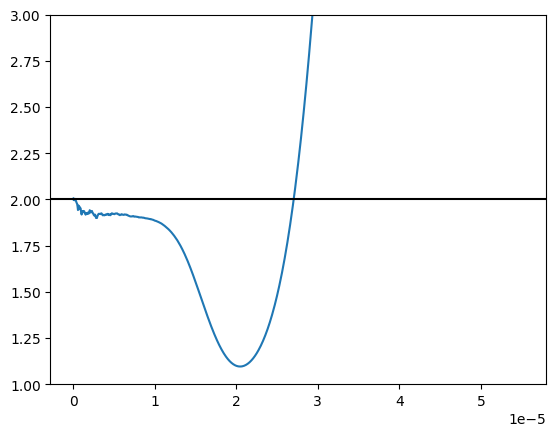

PyObject <matplotlib.lines.Line2D object at 0x331baeba0>

In [77]:
plot(t_grid, out.g[:,2])
ylim(bottom = 1.0, top = 3.0)
axhline(2.0, color = "k")

  seed MC c = 20: 2000/20000 trajectories
  seed MC c = 20: 4000/20000 trajectories
  seed MC c = 20: 6000/20000 trajectories
  seed MC c = 20: 8000/20000 trajectories
  seed MC c = 20: 10000/20000 trajectories
  seed MC c = 20: 12000/20000 trajectories
  seed MC c = 20: 14000/20000 trajectories
  seed MC c = 20: 16000/20000 trajectories
  seed MC c = 20: 18000/20000 trajectories
  seed MC c = 20: 20000/20000 trajectories


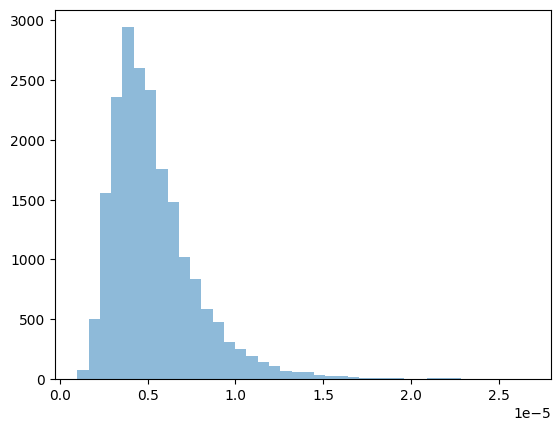

([77.0, 500.0, 1555.0, 2355.0, 2941.0, 2603.0, 2415.0, 1756.0, 1476.0, 1023.0  …  4.0, 6.0, 6.0, 7.0, 5.0, 3.0, 0.0, 3.0, 4.0, 1.0], [9.853338041950763e-7, 1.6281420835293035e-6, 2.2709503628635307e-6, 2.9137586421977577e-6, 3.556566921531985e-6, 4.199375200866212e-6, 4.8421834802004395e-6, 5.484991759534667e-6, 6.127800038868894e-6, 6.770608318203122e-6  …  2.091239046355612e-5, 2.1555198742890346e-5, 2.219800702222457e-5, 2.28408153015588e-5, 2.3483623580893026e-5, 2.4126431860227255e-5, 2.476924013956148e-5, 2.541204841889571e-5, 2.6054856698229936e-5, 2.6697664977564165e-5], (PyObject <matplotlib.patches.Rectangle object at 0x38dea9950>, PyObject <matplotlib.patches.Rectangle object at 0x38dea9a90>, PyObject <matplotlib.patches.Rectangle object at 0x38dea9bd0>, PyObject <matplotlib.patches.Rectangle object at 0x38dea9d10>, PyObject <matplotlib.patches.Rectangle object at 0x38dea9e50>, PyObject <matplotlib.patches.Rectangle object at 0x38dea9f90>, PyObject <matplotlib.patches.Rectan

In [ ]:
function run_seed_trajectory(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    c::Float64;
    M0::Int = N ÷ 2,
    S0::Int = N ÷ 2,
)
    S::Int = S0
    M::Int = M0
    t = 0.0
    threshold = c * Float64(N)
    G1 = dicke_Gn(S, M, 1)

    if G1 >= threshold
        return (reached = true, t = t, S = S, M = M, G1 = G1)
    end

    while t < t_max
        r_dec = Gamma * A_JM_minus2(S, M) + gamma * P_JM_minus_02(S, M, N)
        r_up = xi * P_JM_z_plus2(S, M, N)
        r_down = xi * P_JM_z_minus2(S, M, N)
        r_dec_down = gamma * P_JM_minus_minus2(S, M, N)
        r_dec_up = gamma * P_JM_minus_plus2(S, M, N)

        r_total = r_dec + r_up + r_down + r_dec_up + r_dec_down
        if r_total <= 1e-10
            return (reached = false, t = Inf, S = S, M = M, G1 = G1)
        end

        tau = -log(rand()) / r_total
        t_next = t + tau

        r_val = rand() * r_total
        if r_val < r_dec
            M -= 1
        elseif r_val < r_dec + r_up
            S += 1
        elseif r_val < r_dec + r_up + r_down
            S -= 1
        elseif r_val < r_dec + r_up + r_down + r_dec_up
            S += 1
            M -= 1
        else
            S -= 1
            M -= 1
        end

        t = t_next
        G1 = dicke_Gn(S, M, 1)
        if t <= t_max && G1 >= threshold
            return (reached = true, t = t, S = S, M = M, G1 = G1)
        end
    end

    return (reached = false, t = Inf, S = S, M = M, G1 = G1)
end

function simulate_seed_times(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    c::Float64,
    n_seed::Int,
)
    seeds = Vector{Any}(undef, n_seed)
    for traj in 1:n_seed
        seeds[traj] = run_seed_trajectory(N, Gamma, xi, gamma, t_max, c)
        if traj % max(1, n_seed ÷ 10) == 0
            @printf("  seed MC c = %.4g: %d/%d trajectories\n", c, traj, n_seed)
        end
    end
    return seeds
end

N = 1000000
n_traj = 20000
g_gamma = 0.2
g_xi = 0.3
Γ = 1.0

times = simulate_seed_times(N, Γ, Γ * N * g_xi, Γ * N * g_gamma / log(N), Inf, 20.0, n_traj)
times = map(x -> x.t, times)
replace!(times, Inf => NaN)
n, bins, patches = hist(times, bins = 100; alpha = 0.5)

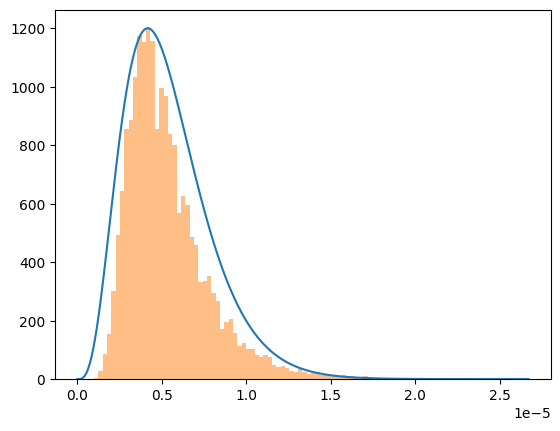

([5.0, 28.0, 85.0, 156.0, 303.0, 493.0, 643.0, 854.0, 886.0, 1034.0  …  0.0, 0.0, 2.0, 1.0, 0.0, 1.0, 2.0, 1.0, 0.0, 1.0], [9.853338041950763e-7, 1.2424571159287671e-6, 1.499580427662458e-6, 1.756703739396149e-6, 2.01382705112984e-6, 2.2709503628635307e-6, 2.5280736745972217e-6, 2.785196986330913e-6, 3.0423202980646034e-6, 3.2994436097982945e-6  …  2.4383555171960948e-5, 2.4640678483694637e-5, 2.489780179542833e-5, 2.5154925107162018e-5, 2.541204841889571e-5, 2.5669171730629403e-5, 2.592629504236309e-5, 2.6183418354096784e-5, 2.6440541665830473e-5, 2.6697664977564165e-5], (PyObject <matplotlib.patches.Rectangle object at 0x398395090>, PyObject <matplotlib.patches.Rectangle object at 0x3983951d0>, PyObject <matplotlib.patches.Rectangle object at 0x398395310>, PyObject <matplotlib.patches.Rectangle object at 0x398395450>, PyObject <matplotlib.patches.Rectangle object at 0x398395590>, PyObject <matplotlib.patches.Rectangle object at 0x3983956d0>, PyObject <matplotlib.patches.Rectangle obj

In [173]:
using Distributions
prune_nans(x) = x[isfinite.(x)]
μ = mean(prune_nans(times))
σ² = var(prune_nans(times))

k = μ^2 / σ²
θ = σ² / μ

d = Distributions.Gamma(k, θ)
x = range(0, maximum(prune_nans(times)), length = 1000)
plot(x, pdf.(d, x) / maximum( pdf.(d, x)) * 1200)
n, bins, patches = hist(times, bins = 100; alpha = 0.5)

In [157]:
d(0.1)

LoadError: MethodError: objects of type Gamma{Float64} are not callable
The object of type `Gamma{Float64}` exists, but no method is defined for this combination of argument types when trying to treat it as a callable object.

N = 1000000
Float64(N) ^ α = 15.848931924611136
  seed MC c = 2: 100/1000 trajectories
  seed MC c = 2: 200/1000 trajectories
  seed MC c = 2: 300/1000 trajectories
  seed MC c = 2: 400/1000 trajectories
  seed MC c = 2: 500/1000 trajectories
  seed MC c = 2: 600/1000 trajectories
  seed MC c = 2: 700/1000 trajectories
  seed MC c = 2: 800/1000 trajectories
  seed MC c = 2: 900/1000 trajectories
  seed MC c = 2: 1000/1000 trajectories
  seed MC c = 0.2: 100/1000 trajectories
  seed MC c = 0.2: 200/1000 trajectories
  seed MC c = 0.2: 300/1000 trajectories
  seed MC c = 0.2: 400/1000 trajectories
  seed MC c = 0.2: 500/1000 trajectories
  seed MC c = 0.2: 600/1000 trajectories
  seed MC c = 0.2: 700/1000 trajectories
  seed MC c = 0.2: 800/1000 trajectories
  seed MC c = 0.2: 900/1000 trajectories
  seed MC c = 0.2: 1000/1000 trajectories


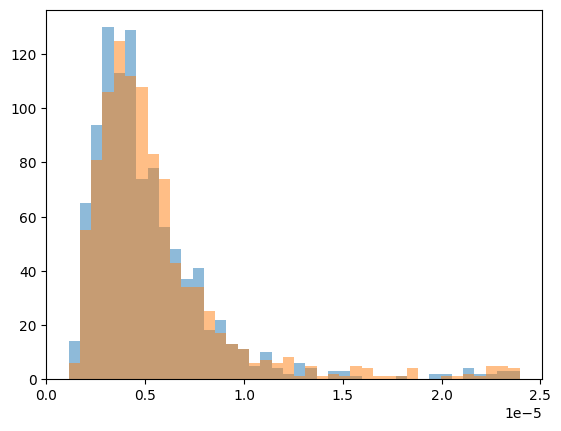

([6.0, 55.0, 81.0, 106.0, 125.0, 112.0, 108.0, 83.0, 74.0, 43.0  …  4.0, 0.0, 0.0, 1.0, 1.0, 2.0, 1.0, 5.0, 5.0, 4.0], [1.127945049290932e-6, 1.6984129976649053e-6, 2.2688809460388785e-6, 2.839348894412852e-6, 3.409816842786825e-6, 3.9802847911607984e-6, 4.550752739534772e-6, 5.121220687908745e-6, 5.691688636282718e-6, 6.262156584656692e-6  …  1.8812451448884103e-5, 1.9382919397258075e-5, 1.9953387345632047e-5, 2.0523855294006022e-5, 2.1094323242379994e-5, 2.166479119075397e-5, 2.223525913912794e-5, 2.2805727087501913e-5, 2.337619503587589e-5, 2.394666298424986e-5], (PyObject <matplotlib.patches.Rectangle object at 0x381de2d50>, PyObject <matplotlib.patches.Rectangle object at 0x381de1950>, PyObject <matplotlib.patches.Rectangle object at 0x381de2e90>, PyObject <matplotlib.patches.Rectangle object at 0x381de2fd0>, PyObject <matplotlib.patches.Rectangle object at 0x381de3110>, PyObject <matplotlib.patches.Rectangle object at 0x381de3250>, PyObject <matplotlib.patches.Rectangle object at

In [138]:
function run_seed_trajectory(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    α::Float64;
    M0::Int = N ÷ 2,
    S0::Int = N ÷ 2,
    rate_order::Symbol = :invN,
)
    rate_order in (:N, :one, :invN) ||
        error("rate_order must be one of :N, :one, :invN")

    S::Int = S0
    M::Int = M0
    t = 0.0
    threshold = Float64(N) ^ α
    G1 = dicke_Gn(S, M, 1)
    nminus = S - M

    if nminus >= threshold
        return (reached = true, t = t, S = S, M = M, G1 = G1)
    end

    while t < t_max
        nplus = S + M
        nminus = S - M
        

        if nplus <= 0
            return (reached = false, t = Inf, S = S, M = M, G1 = G1)
        end

        np = nplus / N

        # Collective decay: M -> M - 1
        r_dec = Gamma * nplus * (nminus + 1)

        # xi_+: S -> S + 1
        r_up = 0.0

        # xi_-: S -> S - 1
        r_down = 0.0

        # gamma_+: S -> S + 1, M -> M - 1
        r_dec_up = 0.0

        # gamma_0: M -> M - 1 at fixed S
        r_dec_0 = 0.0

        # gamma_-: S -> S - 1, M -> M - 1
        r_dec_down = 0.0

        if rate_order in (:N, :one, :invN)
            r_dec_down += 0.5 * (1 + np) * gamma * N
        end

        if rate_order in (:one, :invN)
            r_up += 0.5 * (1 + nminus) * (1 - np) / np * xi
            r_down += 0.5 * nminus * (1 + np) / np * xi
            r_dec_0 += (1 + nminus) / np * gamma
            r_dec_down += -0.5 * (2 + nminus * (2 + np)) / np * gamma
        end

        if rate_order == :invN
            r_dec_up += 0.5 * (2 + 3nminus) * (1 - np) / (np^2 * N) * gamma
        end

        r_dec = max(r_dec, 0.0)
        r_up = max(r_up, 0.0)
        r_down = max(r_down, 0.0)
        r_dec_up = max(r_dec_up, 0.0)
        r_dec_0 = max(r_dec_0, 0.0)
        r_dec_down = max(r_dec_down, 0.0)

        r_total = r_dec + r_up + r_down + r_dec_up + r_dec_0 + r_dec_down

        if r_total <= 1e-10
            return (reached = false, t = Inf, S = S, M = M, G1 = G1)
        end

        tau = -log(rand()) / r_total
        t_next = t + tau

        r_val = rand() * r_total

        if r_val < r_dec + r_dec_0
            M -= 1
        elseif r_val < r_dec + r_dec_0 + r_up
            S += 1
        elseif r_val < r_dec + r_dec_0 + r_up + r_down
            S -= 1
        elseif r_val < r_dec + r_dec_0 + r_up + r_down + r_dec_up
            S += 1
            M -= 1
        else
            S -= 1
            M -= 1
        end

        t = t_next
        G1 = dicke_Gn(S, M, 1)

        if t <= t_max && nminus >= threshold
            return (reached = true, t = t, S = S, M = M, G1 = G1)
        end
    end

    return (reached = false, t = Inf, S = S, M = M, G1 = G1)
end

function simulate_seed_times(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    α::Float64,
    n_seed::Int,
    rate_order
)
    @show N
    @show Float64(N) ^ α
    seeds = Vector{Any}(undef, n_seed)
    for traj in 1:n_seed
        seeds[traj] = run_seed_trajectory(N, Gamma, xi, gamma, t_max, α; rate_order = rate_order)
        if traj % max(1, n_seed ÷ 10) == 0
            @printf("  seed MC c = %.4g: %d/%d trajectories\n", c, traj, n_seed)
        end
    end
    return seeds
end

N = 1000000
n_traj = 1000
g_gamma = 0.4
g_xi = 0.3
Γ = 1.0
α = 0.2

times = simulate_seed_times(N, Γ, Γ * N * g_xi, Γ * N * g_gamma / log(N), 1e3, α, n_traj, :one)
times = map(x -> x.t, times)
replace!(times, Inf => NaN)
n, bins, patches = hist(times, bins = 40; alpha = 0.5)

times = simulate_seed_times(N, Γ, Γ * N * g_xi, Γ * N * g_gamma / log(N), 1e3, α, n_traj)
times = map(x -> x.t, times)
replace!(times, Inf => NaN)
hist(times, bins = bins; alpha = 0.5)

In [2]:
function seed_rates(
    S::Int,
    M::Int,
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    rate_order::Symbol,
)
    rate_order in (:full, :N, :one, :invN) ||
        error("rate_order must be one of :full, :N, :one, :invN")

    if rate_order == :full
        r_dec = Gamma * A_JM_minus2(S, M) + gamma * P_JM_minus_02(S, M, N)
        r_up = xi * P_JM_z_plus2(S, M, N)
        r_down = xi * P_JM_z_minus2(S, M, N)
        r_dec_down = gamma * P_JM_minus_minus2(S, M, N)
        r_dec_up = gamma * P_JM_minus_plus2(S, M, N)

        return (
            r_dec = max(r_dec, 0.0),
            r_up = max(r_up, 0.0),
            r_down = max(r_down, 0.0),
            r_dec_up = max(r_dec_up, 0.0),
            r_dec_down = max(r_dec_down, 0.0),
        )
    end

    nplus = S + M
    nminus = S - M

    if nplus <= 0
        return (r_dec = 0.0, r_up = 0.0, r_down = 0.0, r_dec_up = 0.0, r_dec_down = 0.0)
    end

    np = nplus / N

    r_dec = Gamma * nplus * (nminus + 1)
    r_up = 0.0
    r_down = 0.0
    r_dec_0 = 0.0
    r_dec_up = 0.0
    r_dec_down = 0.0

    if rate_order in (:N, :one, :invN)
        r_dec_down += 0.5 * (1 + np) * gamma * N
    end

    if rate_order in (:one, :invN)
        r_up += 0.5 * (1 + nminus) * (1 - np) / np * xi
        r_down += 0.5 * nminus * (1 + np) / np * xi
        r_dec_0 += (1 + nminus) / np * gamma
        r_dec_down += -0.5 * (2 + nminus * (2 + np)) / np * gamma
    end

    if rate_order == :invN
        r_dec_up += 0.5 * (2 + 3nminus) * (1 - np) / (np^2 * N) * gamma
    end

    return (
        r_dec = max(r_dec + r_dec_0, 0.0),
        r_up = max(r_up, 0.0),
        r_down = max(r_down, 0.0),
        r_dec_up = max(r_dec_up, 0.0),
        r_dec_down = max(r_dec_down, 0.0),
    )
end


function run_seed_trajectory(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    α::Float64;
    M0::Int = N ÷ 2,
    S0::Int = N ÷ 2,
    rate_order::Symbol = :one,
    store_history::Bool = true,
)
    S::Int = S0
    M::Int = M0
    t = 0.0
    threshold = Float64(N)^α

    ts = Float64[t]
    Ss = Int[S]
    Ms = Int[M]

    G1 = dicke_Gn(S, M, 1)

    if S - M >= threshold
        return (
            reached = true,
            t = t,
            S = S,
            M = M,
            G1 = G1,
            ts = ts,
            Ss = Ss,
            Ms = Ms,
        )
    end

    while t < t_max
        rates = seed_rates(S, M, N, Gamma, xi, gamma, rate_order)

        r_total = rates.r_dec + rates.r_up + rates.r_down + rates.r_dec_up + rates.r_dec_down

        if r_total <= 1e-10
            return (
                reached = false,
                t = Inf,
                S = S,
                M = M,
                G1 = G1,
                ts = ts,
                Ss = Ss,
                Ms = Ms,
            )
        end

        tau = -log(rand()) / r_total
        t_next = t + tau

        r_val = rand() * r_total

        if r_val < rates.r_dec
            M -= 1
        elseif r_val < rates.r_dec + rates.r_up
            S += 1
        elseif r_val < rates.r_dec + rates.r_up + rates.r_down
            S -= 1
        elseif r_val < rates.r_dec + rates.r_up + rates.r_down + rates.r_dec_up
            S += 1
            M -= 1
        else
            S -= 1
            M -= 1
        end

        t = t_next
        G1 = dicke_Gn(S, M, 1)

        if store_history
            push!(ts, t)
            push!(Ss, S)
            push!(Ms, M)
        end

        # Important: check threshold after updating S,M.
        if t <= t_max && S - M >= threshold
            return (
                reached = true,
                t = t,
                S = S,
                M = M,
                G1 = G1,
                ts = ts,
                Ss = Ss,
                Ms = Ms,
            )
        end
    end

    return (
        reached = false,
        t = Inf,
        S = S,
        M = M,
        G1 = G1,
        ts = ts,
        Ss = Ss,
        Ms = Ms,
    )
end


function simulate_hybrid_seed_mf_G1_G2(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_grid,
    α::Float64,
    n_traj::Int;
    rate_order::Symbol = :one,
    continuation::Symbol = :seed_state,
    reltol = 1e-9,
    abstol = 1e-11,
)
    t_max = Float64(last(t_grid))
    sums_G1 = zeros(Float64, length(t_grid))
    sums_G2 = zeros(Float64, length(t_grid))

    seeds = Vector{Any}(undef, n_traj)
    cache = Dict{Any, Any}()

    n_reached = 0

    for traj in 1:n_traj
        seed = run_seed_trajectory(
            N, Gamma, xi, gamma, t_max, α;
            rate_order = rate_order,
            store_history = true,
        )

        seeds[traj] = seed

        if seed.reached
            n_reached += 1

            if continuation == :seed_state
                key = (seed.S, seed.M)
                I0 = seed.G1 / Float64(N)^2
                m0 = Float64(seed.M) / Float64(N)
            elseif continuation == :fixed
                key = :fixed
                I0 = Float64(N)^α / Float64(N)^2
                m0 = 0.5
            else
                error("continuation must be :seed_state or :fixed")
            end

            sol = get!(cache, key) do
                solve_seed_meanfield(
                    N, Gamma, xi, gamma, t_max, I0, m0;
                    reltol = reltol,
                    abstol = abstol,
                )
            end

            idx = 1

            for (i, t) in enumerate(t_grid)
                if t < seed.t
                    while idx < length(seed.ts) && seed.ts[idx + 1] <= t
                        idx += 1
                    end

                    S_mc = seed.Ss[idx]
                    M_mc = seed.Ms[idx]

                    sums_G1[i] += dicke_Gn(S_mc, M_mc, 1)
                    sums_G2[i] += dicke_Gn(S_mc, M_mc, 2)
                else
                    t_rel = t - seed.t

                    Ifrak = max(Float64(sol(t_rel)[1]), 0.0)
                    G1 = Float64(N)^2 * Ifrak

                    # Mean-field continuation.
                    # This is a factorized proxy for G2.
                    G2 = G1^2

                    sums_G1[i] += G1
                    sums_G2[i] += G2
                end
            end
        else
            idx = 1

            for (i, t) in enumerate(t_grid)
                while idx < length(seed.ts) && seed.ts[idx + 1] <= t
                    idx += 1
                end

                S_mc = seed.Ss[idx]
                M_mc = seed.Ms[idx]

                sums_G1[i] += dicke_Gn(S_mc, M_mc, 1)
                sums_G2[i] += dicke_Gn(S_mc, M_mc, 2)
            end
        end

        if traj % max(1, n_traj ÷ 10) == 0
            @printf(
                "  hybrid seed+MF α = %.4g, %s: %d/%d trajectories\n",
                α,
                string(rate_order),
                traj,
                n_traj,
            )
        end
    end

    G1 = sums_G1 ./ n_traj
    G2 = sums_G2 ./ n_traj
    g2 = safe_divide(G2, G1 .^ 2)

    return (
        t = collect(t_grid),
        G1 = G1,
        G2 = G2,
        g2 = g2,
        seeds = seeds,
        reached_fraction = n_reached / n_traj,
        n_unique_meanfield_paths = length(cache),
        rate_order = rate_order,
        continuation = continuation,
    )
end

simulate_hybrid_seed_mf_G1_G2 (generic function with 1 method)

  hybrid seed+MF α = 0.6, one: 400/4000 trajectories
  hybrid seed+MF α = 0.6, one: 800/4000 trajectories
  hybrid seed+MF α = 0.6, one: 1200/4000 trajectories
  hybrid seed+MF α = 0.6, one: 1600/4000 trajectories
  hybrid seed+MF α = 0.6, one: 2000/4000 trajectories
  hybrid seed+MF α = 0.6, one: 2400/4000 trajectories
  hybrid seed+MF α = 0.6, one: 2800/4000 trajectories
  hybrid seed+MF α = 0.6, one: 3200/4000 trajectories
  hybrid seed+MF α = 0.6, one: 3600/4000 trajectories
  hybrid seed+MF α = 0.6, one: 4000/4000 trajectories
  hybrid seed+MF α = 0.6, N: 400/4000 trajectories
  hybrid seed+MF α = 0.6, N: 800/4000 trajectories
  hybrid seed+MF α = 0.6, N: 1200/4000 trajectories
  hybrid seed+MF α = 0.6, N: 1600/4000 trajectories
  hybrid seed+MF α = 0.6, N: 2000/4000 trajectories
  hybrid seed+MF α = 0.6, N: 2400/4000 trajectories
  hybrid seed+MF α = 0.6, N: 2800/4000 trajectories
  hybrid seed+MF α = 0.6, N: 3200/4000 trajectories
  hybrid seed+MF α = 0.6, N: 3600/4000 trajector

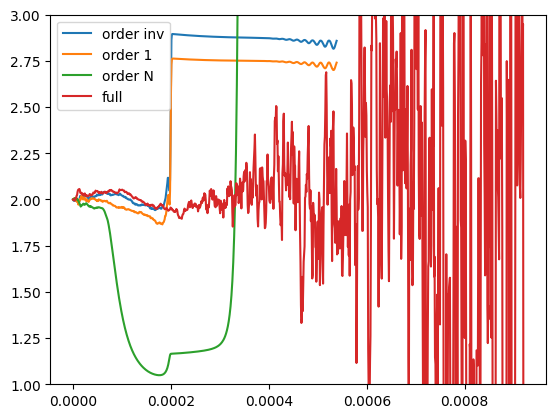

PyObject <matplotlib.legend.Legend object at 0xf566ce900>

In [66]:
N = 100000
n_traj = 4000
g_gamma = 0.4
g_xi = 0.4
Γ = 1.0
α = 0.6

xi = Γ * N * g_xi
gamma = Γ * N * g_gamma / log(N)

t_max = 8.0 * log(N) / (N * Γ)
t_grid = collect(range(0.0, t_max, length = 1000))

out_lin = simulate_hybrid_seed_mf_G1_G2(N, Γ, xi, gamma, t_grid, α, n_traj; rate_order = :one)
out_N = simulate_hybrid_seed_mf_G1_G2(N, Γ, xi, gamma, t_grid, α, n_traj; rate_order = :N)
out_inv = simulate_hybrid_seed_mf_G1_G2(N, Γ, xi, gamma, t_grid, α, n_traj; rate_order = :invN)
out_full = simulate_full_jump_reference(N, Γ, xi, gamma, t_grid, [1,2], n_traj; store_histories = false)

plot(t_grid, out_inv.g2, label = "order inv")
plot(t_grid, out_lin.g2, label = "order 1")
plot(t_grid, out_N.g2, label = "order N")
plot(t_grid, out_full.g[:,2], label = "full")
ylim(bottom = 1.0, top = 3.0)
legend()

In [58]:
out_lin.seeds

4000-element Vector{Any}:
 (reached = true, t = 0.00010522433222161748, S = 26062, M = 25745, G1 = 1.6474626e7, ts = [0.0, 1.3654912184197751e-9, 1.6417703576358268e-8, 1.8078722527941908e-8, 1.8090301594918476e-8, 2.525255088183735e-8, 3.542713339425509e-8, 4.339547723503421e-8, 4.441258964318256e-8, 4.6894825473819204e-8  …  0.00010518739345337076, 0.00010518856049991774, 0.0001051941021325144, 0.00010520448498402254, 0.00010520628639582852, 0.0001052093042436954, 0.00010521856434636532, 0.0001052193156015421, 0.00010522144853710351, 0.00010522433222161748], Ss = [50000, 49999, 49998, 49997, 49996, 49995, 49994, 49993, 49992, 49991  …  26069, 26068, 26067, 26066, 26065, 26065, 26064, 26063, 26062, 26062], Ms = [50000, 49999, 49998, 49997, 49996, 49995, 49994, 49993, 49992, 49991  …  25754, 25753, 25752, 25751, 25750, 25749, 25748, 25747, 25746, 25745])
 (reached = true, t = 0.00010887048789219859, S = 25139, M = 24822, G1 = 1.5887598e7, ts = [0.0, 1.9493997167092595e-9, 8.72534789147